In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path(".").resolve()))

import matplotlib.pyplot as plt
import pandas as pd

from experiments.loader import load_generated

In [2]:
df = load_generated()
df.head()

,llm,mapping,crml,domain,requirement,attempt,model,api_calls,input_tokens,output_tokens,total_tokens,duration_s,tokens_per_s,cache_read_tokens,cache_write_tokens
0,claude,"{'R1_T': None, 'R2_T': None, 'R_T': None, 'R_s...",/home/ubuntu/crml/vol/CRML/LLM/generated/claud...,SRI,speed,1,claude-sonnet-4-5,5,14157,591,14748,18.933,31.2,0.0,0.0
1,claude,"{'R1_T': None, 'R2_T': None, 'R_T': None, 'R_s...",/home/ubuntu/crml/vol/CRML/LLM/generated/claud...,SRI,speed,2,claude-sonnet-4-5,16,148575,2337,150912,75.067,31.1,0.0,0.0
2,claude,"{'R1_T': None, 'R2_T': None, 'R_T': None, 'R_s...",/home/ubuntu/crml/vol/CRML/LLM/generated/claud...,SRI,speed,3,claude-sonnet-4-5,8,27454,915,28369,32.330,28.3,0.0,0.0
3,claude,"{'R1_T': 'R1', 'R2_T': 'R2', 'R_T': None, 'R_s...",/home/ubuntu/crml/vol/CRML/LLM/generated/claud...,SRI,temp,1,claude-sonnet-4-5,12,78622,2528,81150,54.273,46.6,0.0,0.0
4,claude,"{'R1_T': 'req1', 'R2_T': 'req2', 'R_T': None, ...",/home/ubuntu/crml/vol/CRML/LLM/generated/claud...,SRI,temp,2,claude-sonnet-4-5,12,60528,2329,62857,56.386,41.3,0.0,0.0


In [3]:
# Sum total_tokens across attempts for each (llm, domain, requirement)
agg = (
    df.groupby(["llm", "domain", "requirement"], as_index=False)["total_tokens"]
    .sum()
)
agg

,llm,domain,requirement,total_tokens
0,claude,SRI,speed,194029
1,claude,SRI,temp,239152
2,openai,SRI,speed,45080
3,openai,SRI,temp,275240
4,qwen3.5_27b,SRI,speed,86445
5,qwen3.5_27b,SRI,temp,399635


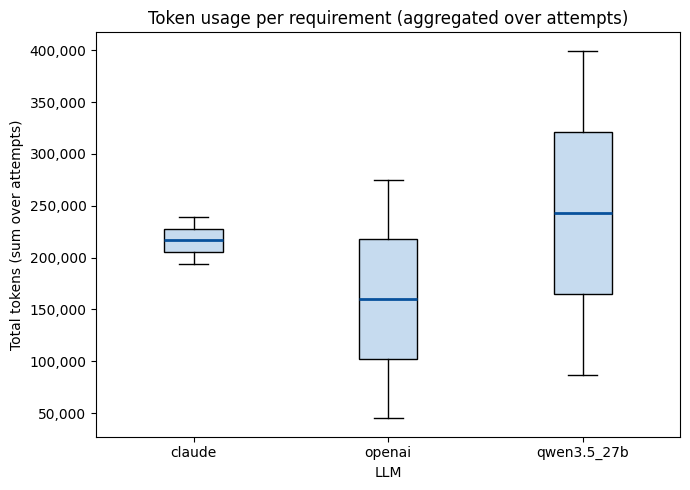

In [4]:
llms = sorted(agg["llm"].unique())
data = [agg.loc[agg["llm"] == llm, "total_tokens"].values for llm in llms]

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(data, tick_labels=llms, patch_artist=True,
           boxprops=dict(facecolor="#c6dbef"),
           medianprops=dict(color="#08519c", linewidth=2))

ax.set_ylabel("Total tokens (sum over attempts)")
ax.set_xlabel("LLM")
ax.set_title("Token usage per requirement (aggregated over attempts)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("figures_total_tokens.pdf", bbox_inches="tight")
plt.show()